In [ ]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 19.6 MB/s eta 0:00:00


In [ ]:
import cv2
import os

In [ ]:
# Define paths
train_video_path = "/content/Avenue_Dataset/training_videos"
test_video_path = "/content/Avenue_Dataset/testing_videos"
train_frame_path = "/content/Avenue_Dataset/frames/train"
test_frame_path = "/content/Avenue_Dataset/frames/test"

In [ ]:
# Create directories
os.makedirs(train_frame_path, exist_ok=True)
os.makedirs(test_frame_path, exist_ok=True)

In [ ]:
def extract_frames(video_folder, output_folder, frame_interval=10):
    """
    Extracts frames from videos at a given interval and saves them.

    Args:
        video_folder (str): Path to folder containing videos.
        output_folder (str): Path to save extracted frames.
        frame_interval (int): Save every nth frame (default=10).
    """
    for video_file in os.listdir(video_folder):
        if video_file.endswith(".mp4") or video_file.endswith(".avi"):
            video_path = os.path.join(video_folder, video_file)
            cap = cv2.VideoCapture(video_path)
            count = 0
            frame_id = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                if count % frame_interval == 0:
                    frame_filename = os.path.join(output_folder, f"{video_file}_frame_{frame_id}.jpg")
                    cv2.imwrite(frame_filename, frame)
                    frame_id += 1

                count += 1

            cap.release()
            print(f"Frames extracted from {video_file}")

    print(f"Frames saved in {output_folder}")

In [ ]:
# Extract frames from training and testing videos
extract_frames(train_video_path, train_frame_path)
extract_frames(test_video_path, test_frame_path)

print("Frame extraction completed!")

Frames extracted from 06.avi
Frames extracted from 11.avi
Frames extracted from 02.avi
Frames extracted from 03.avi
Frames extracted from 16.avi
Frames extracted from 04.avi
Frames extracted from 15.avi
Frames extracted from 14.avi
Frames extracted from 05.avi
Frames extracted from 13.avi
Frames extracted from 01.avi
Frames extracted from 10.avi
Frames extracted from 09.avi
Frames extracted from 07.avi
Frames extracted from 08.avi
Frames extracted from 12.avi
Frames saved in /content/Avenue_Dataset/frames/train
Frames extracted from 06.avi
Frames extracted from 20.avi
Frames extracted from 11.avi
Frames extracted from 02.avi
Frames extracted from 03.avi
Frames extracted from 21.avi
Frames extracted from 16.avi
Frames extracted from 19.avi
Frames extracted from 17.avi
Frames extracted from 04.avi
Frames extracted from 15.avi
Frames extracted from 14.avi
Frames extracted from 05.avi
Frames extracted from 13.avi
Frames extracted from 01.avi
Frames extracted from 10.avi
Frames extracted fr

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.9/976.9 kB 14.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Load pre-trained YOLOv8 model (for auto-annotation)
model = YOLO("yolov8n.pt")

100%|██████████| 6.25M/6.25M [00:00<00:00, 65.8MB/s]


In [ ]:
# Define paths
frames_dir = "/content/Avenue_Dataset/frames"
labels_dir = "/content/Avenue_Dataset/labels"

In [ ]:
# Create label folders
train_labels_path = os.path.join(labels_dir, "train")
test_labels_path = os.path.join(labels_dir, "test")
os.makedirs(train_labels_path, exist_ok=True)
os.makedirs(test_labels_path, exist_ok=True)


In [ ]:
def annotate_images(frame_folder, label_folder):
    """
    Runs YOLO inference on frames and saves detected objects in YOLO format.
    """
    for frame_file in os.listdir(frame_folder):
        if frame_file.endswith(".jpg"):
            frame_path = os.path.join(frame_folder, frame_file)
            image = cv2.imread(frame_path)

            # Run YOLO detection
            results = model(image)

            # Save labels in YOLO format
            label_file = os.path.join(label_folder, frame_file.replace(".jpg", ".txt"))
            with open(label_file, "w") as f:
                for r in results:
                    for box in r.boxes:
                        x_center, y_center, width, height = box.xywhn[0]  # Normalized coordinates
                        class_id = int(box.cls[0])  # Class ID

                        # Write YOLO format: class x_center y_center width height
                        f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")

            print(f"Annotated: {frame_file}")

In [ ]:
# Annotate training and testing frames
annotate_images(os.path.join(frames_dir, "train"), train_labels_path)
annotate_images(os.path.join(frames_dir, "test"), test_labels_path)

print("Auto-annotation completed! 🚀")

Streaming output truncated to the last 5000 lines.
0: 384x640 6 persons, 3 handbags, 41.4ms
Speed: 49.7ms preprocess, 41.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Annotated: 02.avi_frame_91.jpg

0: 384x640 9 persons, 1 backpack, 2 handbags, 40.0ms
Speed: 1.2ms preprocess, 40.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
Annotated: 05.avi_frame_71.jpg

0: 384x640 6 persons, 94.3ms
Speed: 1.5ms preprocess, 94.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Annotated: 04.avi_frame_78.jpg

0: 384x640 17 persons, 4 handbags, 94.1ms
Speed: 1.6ms preprocess, 94.1ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Annotated: 19.avi_frame_14.jpg

0: 384x640 8 persons, 2 handbags, 95.1ms
Speed: 1.2ms preprocess, 95.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
Annotated: 01.avi_frame_71.jpg

0: 384x640 7 persons, 2 handbags, 1 suitcase, 97.7ms
Speed: 1.6ms preprocess, 97.7ms inference, 0

In [ ]:
# Paths
frames_dir = "/content/Avenue_Dataset/frames/train"  # Change to "test" if needed
labels_dir = "/content/Avenue_Dataset/labels/train"

In [ ]:
# Class names (Using COCO dataset for now, but we can modify this based on detected classes)
CLASS_NAMES = ["person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat", "traffic light",
               "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow"]

In [ ]:
import cv2
import os
from google.colab.patches import cv2_imshow

In [ ]:
def visualize_annotations(image_file):
    """Loads an image and its YOLO annotation, then displays the bounding boxes."""
    img_path = os.path.join(frames_dir, image_file)
    label_path = os.path.join(labels_dir, image_file.replace(".jpg", ".txt"))

    # Load image
    image = cv2.imread(img_path)
    h, w, _ = image.shape  # Image dimensions

    # Read annotation file
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            class_id = int(parts[0])
            x_center, y_center, box_width, box_height = map(float, parts[1:])

            # Convert YOLO format (normalized) to pixel values
            x1 = int((x_center - box_width / 2) * w)
            y1 = int((y_center - box_height / 2) * h)
            x2 = int((x_center + box_width / 2) * w)
            y2 = int((y_center + box_height / 2) * h)

            # Draw bounding box
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f"Class {class_id}"
            cv2.putText(image, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Show image in Colab
    cv2_imshow(image)

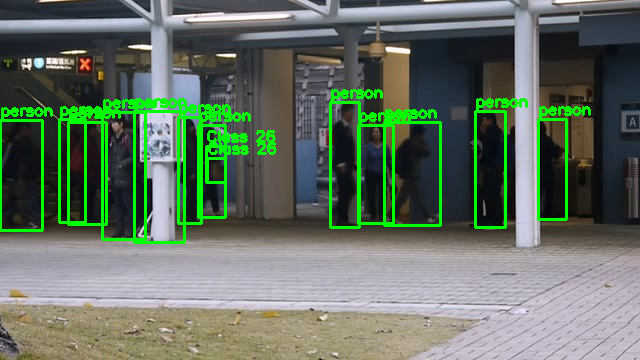

In [ ]:
# Example: Pick any image from the training set
sample_image = os.listdir(frames_dir)[0]  # Pick the first image
visualize_annotations(sample_image)

In [ ]:
from ultralytics import YOLO

In [ ]:
import os

# Define paths
dataset_path = "/content/Avenue_Dataset"

# Rename frames to images
os.rename(os.path.join(dataset_path, "frames"), os.path.join(dataset_path, "images"))

print("Renamed 'frames/' to 'images/' successfully!")


Renamed 'frames/' to 'images/' successfully!


In [ ]:
# Train on Avenue Dataset
model.train(data="/content/Avenue_Dataset/dataset.yaml", epochs=20, imgsz=640, batch=8,lr0=0.001)

Ultralytics 8.3.99 🚀 Python-3.11.11 torch-2.6.0+cpu CPU (Intel Xeon 2.00GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/Avenue_Dataset/dataset.yaml, epochs=5, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_b

100%|██████████| 755k/755k [00:00<00:00, 14.4MB/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

Model summary: 129 layers, 3,011,043 parameters, 3,011,027 gradients, 8.2 GFLOPs

Transferred 58/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'


train: Scanning /content/Avenue_Dataset/labels/train... 1542 images, 0 backgrounds, 711 corrupt: 100%|██████████| 1542/1542 [00:01<00:00, 1501.32it/s]

...

                   all        649       4181      0.926      0.873      0.947      0.762



5 epochs completed in 0.286 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 6.2MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.99 🚀 Python-3.11.11 torch-2.6.0+cpu CPU (Intel Xeon 2.00GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 41/41 [00:26<00:00,  1.55it/s]


                   all        649       4181      0.925      0.874      0.947      0.762
Speed: 0.4ms preprocess, 30.4ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to runs/detect/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d15206e0e50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO
import cv2

# Load trained model
model = YOLO("/content/runs/detect/train2/weights/best.pt")

# Path to test video
video_path = "/content/Avenue_Dataset/testing_videos/03.avi"  # Change to your test video

# Run inference on video
results = model.predict(video_path, save=True, imgsz=640, conf=0.7)

print("Detection complete! Check the saved output video.")




WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/923) /content/Avenue_Dataset/testing_videos/03.avi: 384x640 6 unwanted_activitys, 97.7ms
video 1/1 (frame 2/923) /content/Avenue_Dataset/testing_videos/03.avi: 384x640 6 unwanted_activitys, 91.1ms
video 1/1 (frame 3/923) /content/Avenue_Dataset/testing_videos/03.avi: 384x640 6 unwanted_activitys, 89.8ms
video 1/1 (frame 4/923) /content/Avenue_Dataset/testing_videos/03.avi: 384x640 7 unwanted_activitys, 91.1ms
video 1/1 (frame 5/923) 

In [ ]:
import os

# Check available model weight files
weights_path = "/content/runs/detect/"
for root, dirs, files in os.walk(weights_path):
    for file in files:
        if file.endswith(".pt"):
            print("Found:", os.path.join(root, file))


Found: /content/runs/detect/train2/weights/best.pt
Found: /content/runs/detect/train2/weights/last.pt


In [ ]:
import cv2

# Load trained model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Open webcam
cap = cv2.VideoCapture(0)  # Change to 1 if using an external camera

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Run detection
    results = model(frame)

    # Display results
    annotated_frame = results[0].plot()
    cv2.imshow("Unwanted Activity Detection", annotated_frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


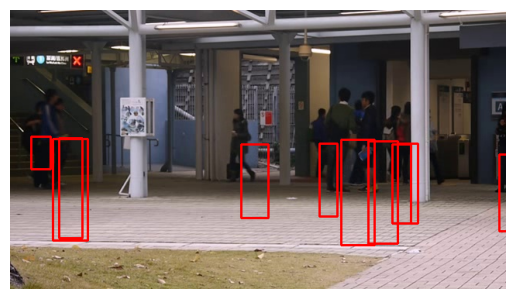

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

# Define paths
images_dir = "/content/Avenue_Dataset/images/train"
labels_dir = "/content/Avenue_Dataset/labels/train"

# Get a random image
image_file = sorted(os.listdir(images_dir))[2]  # First image
image_path = os.path.join(images_dir, image_file)
label_path = os.path.join(labels_dir, image_file.replace(".jpg", ".txt"))

# Read image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Load labels
with open(label_path, "r") as f:
    lines = f.readlines()

# Draw bounding boxes
for line in lines:
    parts = line.strip().split()
    class_id, x, y, w, h = map(float, parts)

    # Convert YOLO format (normalized) to pixel values
    H, W, _ = image.shape
    x, y, w, h = int(x * W), int(y * H), int(w * W), int(h * H)

    # Draw rectangle
    cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

# Show image
plt.imshow(image)
plt.axis("off")
plt.show()


In [ ]:
import os

# Define labels directory
labels_dir = "/content/Avenue_Dataset/labels/train"

# Threshold for removing large boxes (adjust if needed)
MAX_BOX_WIDTH = 0.6  # If the box width is > 60% of the image, remove it
MAX_BOX_HEIGHT = 0.6  # If the box height is > 60% of the image, remove it

# Loop through all label files
for label_file in os.listdir(labels_dir):
    label_path = os.path.join(labels_dir, label_file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        class_id, x, y, w, h = map(float, parts)

        # Remove large boxes (likely normal people standing)
        if w < MAX_BOX_WIDTH and h < MAX_BOX_HEIGHT:
            new_lines.append(line)

    # Save only valid labels
    with open(label_path, "w") as f:
        f.writelines(new_lines)

print("✅ Incorrect labels removed successfully!")


✅ Incorrect labels removed successfully!
